# ***ASSIGNMENT 1: Understanding Generative and Discriminative Models Using MNIST***

###**Name:** Pragathi BR ###

###**Registration No.:** 2411021240037 ###

###**Course:** BCA (Artificial Intelligence & Machine Learning) — BCA AIML ###

###**Subject:** Generative AI ###

###**Date of Submission:** 06-09-2026 ###

###**Faculty Name**: Sanjivini Chowdhury ###

##**Objective**

#####The Objective of this assignment is to understand the difference between discriminative and generative models using the MNIST handwritten digit dataset. #####


####In this notebook, only the digits 0 and 1 are considered. logistic regression is used as a Descriminative model to classify the digits, while an Autoencoder is used as the generative model to learn the patterns of a digit images and reconstruct new examples ####

##**Import Libraries**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

##**Dataset Preparation**

####The MNIST Tetaset contains images of handwritten digits from 0 to 9. For this assignment, only the images representing digits 0 and 1 are selected. ####


####The pixel values are normalized between 0 and 1 so that the models can process the images more efficiently. ####

In [ ]:
#Load MNIST Dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

#Select only digits 0 and 1
train_filter = (y_train == 0) | (y_train ==1)
test_filter = (y_test == 0) | (y_test == 1)

x_train = x_train[train_filter]
y_train = y_train[train_filter]


x_test = x_test[test_filter]
y_test = y_test[test_filter]

#Normalize pixel values
x_train = x_train.astype('float32')/255.0
x_test = x_test.astype('float32')/255.0

print("Training images:", x_train.shape)
print("Test images:", x_test.shape)


Training images: (12665, 28, 28)
Test images: (2115, 28, 28)


##**Samples Images**

####The following images show some examples of digits 0 and 1 from the MNIST dataset. ####

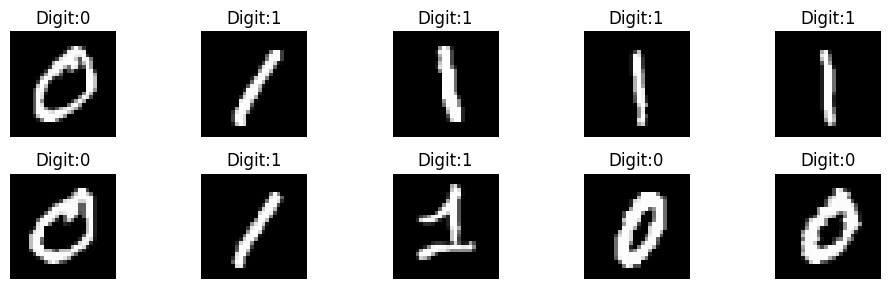

In [ ]:
plt.figure(figsize=(10,3))
for i in range(10):
  plt.subplot(2, 5, i + 1)
  plt.imshow(x_train[i], cmap='gray')
  plt.title("Digit:" + str(y_train[i]))
  plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#Flatten images from 28*28 into 748 features
x_train_flat = x_train.reshape(-1, 28*28)
x_test_flat = x_test.reshape(-1, 28*28)

print("New Training images:", x_train_flat.shape)
print("New Test images:", x_test_flat.shape)

New Training images: (12665, 784)
New Test images: (2115, 784)


##**Discriminative Model - Logistic Regression**

####A discriminative model learns the relationship between the input data and its label. ####


####Here, Logistic Regreesion is trained to distinguish between handwritten digits 0 and 1.
####The model learns a decision boundary that separted the two classes ####



In [ ]:
# Create Logistic Regression model
classifier = LogisticRegression(max_iter=1000)

# Train the model
classifier.fit(x_train_flat, y_train)

# Make predictions on the test set
y_pred = classifier.predict(x_test_flat)

print("Predictions completed.")

Predictions completed.


In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy of Logistic Regression:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Accuracy of Logistic Regression: 0.9995271867612293
Accuracy Percentage: 99.95271867612293 %


##**Visualizing Model Predtictions**

####The following images show the actual digit and the digit predicted by the Logistic Regression model. ####

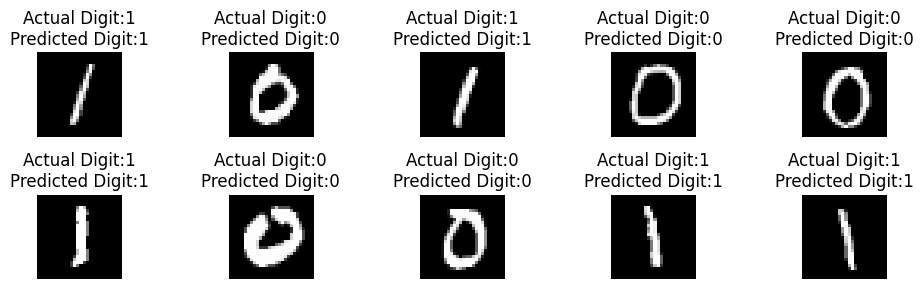

In [ ]:
plt.figure(figsize=(10,3))
for i in range(10):
  plt.subplot(2, 5, i +1)
  plt.imshow(x_test[i], cmap='gray')
  plt.title("Actual Digit:" + str(y_test[i]) + "\nPredicted Digit:" + str(y_pred[i]))
  plt.axis('off')

plt.tight_layout()
plt.show()

##**Generative Model - Autoencoder**

####An Autoencoder is a neural network that learns a compressed representation of the input images. ####

####It consists of an encoder and a decoder. The encoder compresses the image information, while the decoder reconstructs the image. ####

####Unlike the discriminative model, the Autoencoder learns the patterns and structure present in the digit images rather than simply predicting their labels. ####


In [ ]:
# Flatten the images for the Autoencoder
x_train_auto = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test_auto = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

print("New Training images:", x_train_auto.shape)
print("New Test images:", x_test_auto.shape)

New Training images: (12665, 784)
New Test images: (2115, 784)


In [ ]:
# Size of compressed representaion
encoding_dim = 32

#Input Layer
input_img = Input(shape=(784,))

#Encoder
encoded = Dense(128, activation="relu")(input_img)
encoded = Dense(encoding_dim, activation="relu")(encoded)

# Decoder
decoded = Dense(128, activation="relu")(encoded)
decoded = Dense(784, activation="sigmoid")(decoded)

# Create Autoencoder model
autoencoder = Model(input_img, decoded)

autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209,968 (820.19 KB)

 Trainable params: 209,968 (820.19 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = autoencoder.fit(
    x_train_auto,
    x_train_auto,
    epochs=10,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test_auto, x_test_auto)
)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.3452 - val_loss: 0.1688
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.1508 - val_loss: 0.1342
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.1281 - val_loss: 0.1187
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1157 - val_loss: 0.1093
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.1076 - val_loss: 0.1021
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1010 - val_loss: 0.0965
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0956 - val_loss: 0.0918
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0918 - val_loss: 0.0888
Epoch 9/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0889 - val_loss: 0.0859
Epoch 10/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0862 - val_loss: 0.0839


##**Generated / Reconstructed Digit Images**

####The trained Autoencoder is used to reconstruct digit images. These reconstructed images show the patterns learned by the generative model. ####

In [ ]:
# Generate reconstructed images
generated_images = autoencoder.predict(x_test_auto)

67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


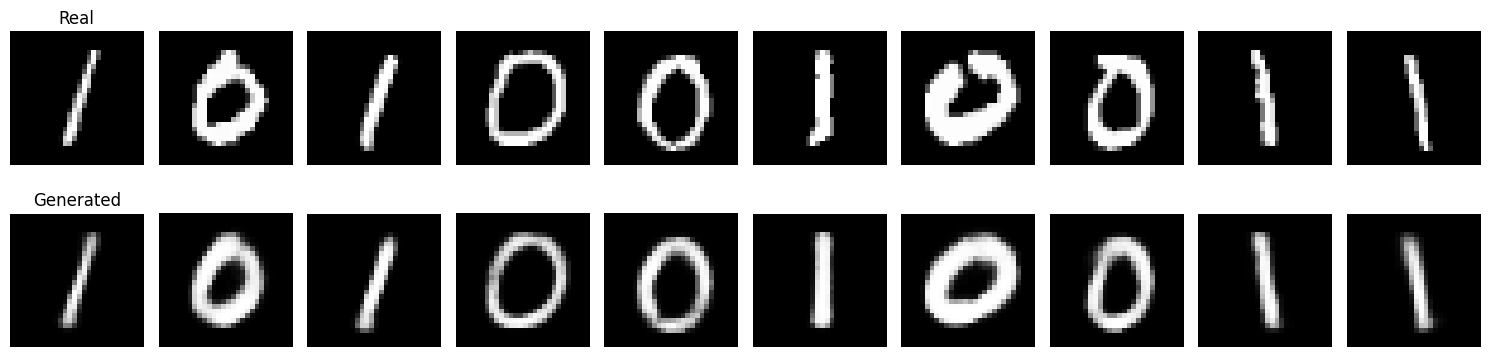

In [ ]:
n = 10

plt.figure(figsize=(15, 4))

for i in range(n):

    # Real images
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_auto[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

    if i == 0:
        ax.set_title("Real")

    # Generated images
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(generated_images[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

    if i == 0:
        ax.set_title("Generated")

plt.tight_layout()
plt.show()

## **Visual Comparison**

####The following visualization compares three things side by side: the original MNIST digit, the class label predicted by the discriminative model (Logistic Regression), and the reconstructed image produced by the generative model (Autoencoder). Note that the discriminative model only outputs a label, not an image, so the same real image is shown with its predicted label for reference. ####

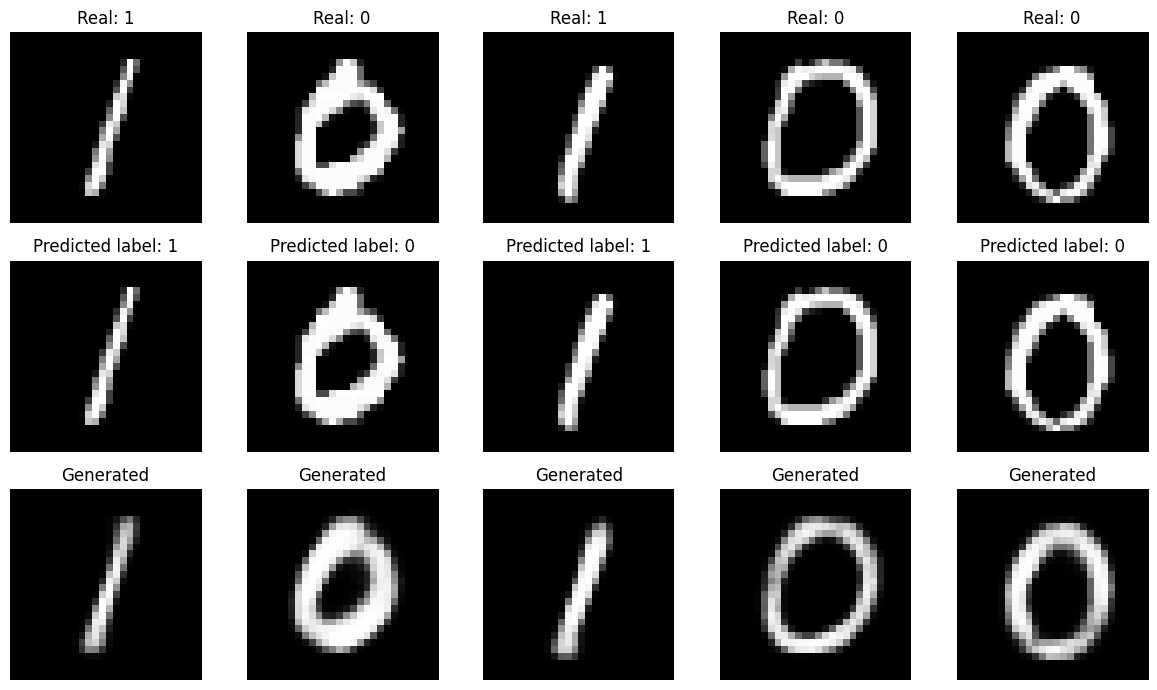

In [ ]:
n = 5

plt.figure(figsize=(12, 7))

for i in range(n):

    # Original image
    plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i], cmap="gray")
    plt.title("Real: " + str(y_test[i]))
    plt.axis("off")

    # Discriminative model's predicted label (same image, model just outputs a class label, not an image)
    plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test[i], cmap="gray")
    plt.title("Predicted label: " + str(y_pred[i]))
    plt.axis("off")

    # Generated/reconstructed image from the Autoencoder
    plt.subplot(3, n, i + 1 + (2 * n))
    plt.imshow(generated_images[i].reshape(28, 28), cmap="gray")
    plt.title("Generated")
    plt.axis("off")

plt.tight_layout()
plt.show()

## **Written Reflection**

####The discriminative model (Logistic Regression) learned a decision boundary that separates digit 0 from digit 1 based on pixel patterns, and it achieved high accuracy at predicting the correct label for unseen images. The generative model (Autoencoder) did not learn to classify at all; instead, it learned the underlying structure and distribution of the digit images well enough to compress and reconstruct them. In short, the discriminative model answers "which class does this belong to?", while the generative model answers "what do these images actually look like?". This is why the discriminative model outputs only a label, whereas the generative model can produce a full image. Both approaches learn from the same data, but they solve fundamentally different problems. ####
